In [36]:
import sys
import warnings

# Suppress minor deprecation warnings (like the TensorFlow internal keras one)
warnings.filterwarnings('ignore')

print("--- SYSTEM CONFIGURATION ---")
print("OS Platform:      ", sys.platform)
print("Python version:   ", sys.version.split('\n')[0])
print("Conda Environment:", sys.prefix)    
print("-" * 30)

from pathlib import Path
import requests

# Core Data Science Frameworks
import sys
print(sys.executable)

import numpy as np
import pandas as pd
import matplotlib
import plotly
import seaborn as sns

print("--- CORE FRAMEWORKS ---")
print("NumPy version:     ", np.__version__)
print("Pandas version:    ", pd.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("Seaborn version:   ", sns.__version__)
print("-" * 30)

# Deep Learning Frameworks
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("--- DEEP LEARNING ---")
print("TensorFlow version:", tf.__version__)
print("-" * 30)

# Statistical & Time Series Modeling
import statsmodels
from statsmodels.tsa.stattools import adfuller

# Machine Learning & Analytics Evaluation Tools
import sklearn
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef, cohen_kappa_score,
    log_loss, brier_score_loss, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
    mean_absolute_error, mean_squared_error
)

print("--- MACHINE LEARNING & STATS ---")
print("Scikit-learn version:", sklearn.__version__)
print("Statsmodels version: ", statsmodels.__version__)
print("-" * 30)

# Hidden Markov Models Block
try:
    import hmmlearn
    from hmmlearn.hmm import GaussianHMM
    print(f"hmmlearn version:    {hmmlearn.__version__}")
    HMMLEARN_AVAILABLE = True
except ImportError:
    HMMLEARN_AVAILABLE = False
    print("hmmlearn is not installed. HMM functionality will be unavailable.")
print("-" * 30)

print("\nAll targeted libraries imported successfully. System ready f!or development")

--- SYSTEM CONFIGURATION ---
OS Platform:       linux
Python version:    3.10.20 (main, Jun 11 2026, 15:17:37) [GCC 14.3.0]
Conda Environment: /home/dev-algo/anaconda3/envs/WLV-TF
------------------------------
/home/dev-algo/anaconda3/envs/WLV-TF/bin/python
--- CORE FRAMEWORKS ---
NumPy version:      1.26.4
Pandas version:     2.3.3
Matplotlib version: 3.10.8
Seaborn version:    0.13.2
------------------------------
--- DEEP LEARNING ---
TensorFlow version: 2.15.1
------------------------------
--- MACHINE LEARNING & STATS ---
Scikit-learn version: 1.7.2
Statsmodels version:  0.14.6
------------------------------
hmmlearn version:    0.3.3
------------------------------

All targeted libraries imported successfully. System ready f!or development


In [37]:
# Load the dataset
csv_path = Path("NYSE_BATS_ORCL_1D.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Dataset not found: {csv_path.resolve()}")

raw_df = pd.read_csv(csv_path, sep=";")
print("Raw shape:", raw_df.shape)
print("Raw columns:", list(raw_df.columns))

df = raw_df.copy()

# Defensive re-parse: some exports land as a single semicolon-delimited column that
# is actually comma-separated. Keep the required market-structure columns exactly.
if df.shape[1] == 1 and df.columns[0].startswith("time,"):
    df = df.iloc[:, 0].str.split(",", expand=True)
    df.columns = [
        "time", "open", "high", "low", "close",
        "SMA_756_Close", "SMA_VWMA_756", "SMA_504_Close", "SMA_VWMA_504",
        "SMA_252_Close", "SMA_125_Close", "SMA_63_Close", "SMA_21_Close",
        "TSI_25_13_13", "TSI_Signal_13", "RSI_25_Close",
        "RSI_SMA_14", "New_Moon", "Full_Moon"
    ]

# Keep only the expected fields in the exact order required downstream.
required_columns = [
    "time", "open", "high", "low", "close",
    "SMA_756_Close", "SMA_VWMA_756", "SMA_504_Close", "SMA_VWMA_504",
    "SMA_252_Close", "SMA_125_Close", "SMA_63_Close", "SMA_21_Close",
    "TSI_25_13_13", "TSI_Signal_13", "RSI_25_Close",
    "RSI_SMA_14", "New_Moon", "Full_Moon"
]
existing_columns = [col for col in required_columns if col in df.columns]
df = df[existing_columns].copy()

# Normalise timestamps and remove invalid/duplicate records.
df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")

invalid_ts = df["time"].isna().sum()
dup_count_before = df.duplicated().sum()

df = df.dropna(subset=["time"]).drop_duplicates().sort_values("time").set_index("time")

# OHLC and indicator values must be numeric before feature generation.
for col in ["open", "high", "low", "close", "SMA_756_Close", "SMA_VWMA_756",
            "SMA_504_Close", "SMA_VWMA_504", "SMA_252_Close", "SMA_125_Close",
            "SMA_63_Close", "SMA_21_Close", "TSI_25_13_13",
            "TSI_Signal_13", "RSI_25_Close", "RSI_SMA_14"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Preserve the moon phase flags as integers/bools if they are not already.
for col in ["New_Moon", "Full_Moon"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nInvalid timestamps removed:", invalid_ts)
print("Duplicate rows removed:", dup_count_before)
print("Final shape:", df.shape)
print("\nMissing values per column:\n", df.isna().sum())
print("\nData types:\n", df.dtypes)

# Return a summary table for the cleaned dataset
summary_table = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isna().sum().values,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

summary_table


Raw shape: (10185, 1)
Raw columns: ['time,open,high,low,close,SMA_756_Close,SMA_VWMA_756,SMA_504_Close,SMA_VWMA_504,SMA_252_Close,SMA_125_Close,SMA_63_Close,SMA_21_Close,TSI_25_13_13,TSI_Signal_13,RSI_25_Close,RSI_SMA_14,New_Moon,Full_Moon']

Invalid timestamps removed: 0
Duplicate rows removed: 0
Final shape: (10185, 18)

Missing values per column:
 open               0
high               0
low                0
close              0
SMA_756_Close    755
SMA_VWMA_756     768
SMA_504_Close    503
SMA_VWMA_504     516
SMA_252_Close    251
SMA_125_Close    124
SMA_63_Close      62
SMA_21_Close      20
TSI_25_13_13      37
TSI_Signal_13     49
RSI_25_Close      25
RSI_SMA_14        38
New_Moon           0
Full_Moon          0
dtype: int64

Data types:
 open             float64
high             float64
low              float64
close            float64
SMA_756_Close    float64
SMA_VWMA_756     float64
SMA_504_Close    float64
SMA_VWMA_504     float64
SMA_252_Close    float64
SMA_125_Close    

,Column,Data Type,Missing Values,Unique Values
0,open,float64,0,5838
1,high,float64,0,5948
2,low,float64,0,6001
3,close,float64,0,5969
4,SMA_756_Close,float64,755,9406
5,SMA_VWMA_756,float64,768,9417
6,SMA_504_Close,float64,503,9670
7,SMA_VWMA_504,float64,516,9669
8,SMA_252_Close,float64,251,9918
9,SMA_125_Close,float64,124,9999


In [38]:
# Display the cleaned dataframe with actual values in table form

df.reset_index().tail(10)

,time,open,high,low,close,SMA_756_Close,SMA_VWMA_756,SMA_504_Close,SMA_VWMA_504,SMA_252_Close,SMA_125_Close,SMA_63_Close,SMA_21_Close,TSI_25_13_13,TSI_Signal_13,RSI_25_Close,RSI_SMA_14,New_Moon,Full_Moon
10175,2026-08-10 00:00:00+00:00,148.260,151.99,146.6200,151.05,162.867870,162.663705,185.194087,185.152522,197.999722,162.16872,165.818095,130.497143,-4.350409,-22.273293,50.883247,41.808621,0,0
10176,2026-08-11 00:00:00+00:00,151.200,151.99,144.2400,145.48,162.908929,162.681625,185.228353,185.149578,197.584762,162.05344,165.050476,131.160952,-2.348540,-19.426900,48.521670,42.667988,0,0
10177,2026-08-12 00:00:00+00:00,152.810,154.89,147.8900,153.28,162.958109,162.711971,185.282679,185.152923,197.190317,162.02240,164.517936,132.367619,1.138778,-16.488946,51.785821,43.877253,0,0
10178,2026-08-13 00:00:00+00:00,151.980,159.26,151.9100,156.22,163.012328,162.740584,185.336766,185.154577,196.802857,162.02032,163.985556,133.497619,4.590848,-13.477547,52.956997,45.267366,1,0
10179,2026-08-14 00:00:00+00:00,155.840,156.39,148.8001,150.52,163.061825,162.768054,185.373393,185.161740,196.431191,161.94336,163.269841,134.750476,5.908904,-10.708054,50.480556,46.299921,0,0
10180,2026-08-17 00:00:00+00:00,148.450,150.40,145.5000,146.65,163.106349,162.796656,185.401309,185.173918,196.041071,161.88480,162.534921,135.714286,5.976252,-8.324582,48.864477,47.214831,0,0
10181,2026-08-18 00:00:00+00:00,143.250,146.00,142.3500,142.79,163.145675,162.825287,185.418234,185.189188,195.622460,161.77776,161.839365,136.733810,5.052806,-6.413526,47.291485,48.064536,0,0
10182,2026-08-19 00:00:00+00:00,142.695,146.08,137.4300,143.81,163.183029,162.869739,185.434524,185.215177,195.204762,161.67592,161.241746,137.531905,4.545954,-4.847886,47.754424,48.588301,0,0
10183,2026-08-20 00:00:00+00:00,144.300,145.92,141.0200,142.07,163.215807,162.904020,185.444722,185.236814,194.837500,161.62784,160.510159,138.304762,3.688181,-3.628448,47.020571,48.980040,0,0
10184,2026-08-21 00:00:00+00:00,143.715,148.35,142.6000,146.47,163.256984,162.955902,185.462579,185.271016,194.485952,161.66912,159.822857,139.563333,4.042427,-2.532609,49.081685,49.135719,0,0


In [43]:
# Oracle Trend Plot with candlesticks and 6 SMA overlays
import plotly.graph_objects as go

# Use the cleaned dataset when available; otherwise create a synthetic example.
if "df" in globals() and not df.empty:
    trend_df = df.reset_index().rename(columns={"time": "Date"})
    trend_df = trend_df[["Date", "open", "high", "low", "close"]].copy()
    trend_df["Date"] = pd.to_datetime(trend_df["Date"])
else:
    np.random.seed(42)
    dates = pd.date_range(start="2020-01-01", periods=900, freq="D")
    base_price = 40 + np.cumsum(np.random.normal(0, 1.5, len(dates)))
    opens = base_price.copy()
    closes = opens + np.random.normal(0, 1.1, len(dates))
    highs = np.maximum(opens, closes) + np.abs(np.random.normal(0, 2.0, len(dates)))
    lows = np.minimum(opens, closes) - np.abs(np.random.normal(0, 2.0, len(dates)))
    trend_df = pd.DataFrame({
        "Date": dates,
        "open": opens,
        "high": highs,
        "low": lows,
        "close": closes,
    })

# Ensure chronological ordering
trend_df = trend_df.sort_values("Date").dropna(subset=["open", "high", "low", "close"]).reset_index(drop=True)

# Build the required 6 SMA columns if they are not already present.
sma_palette = {
    756: "gray",
    504: "white",
    252: "red",
    125: "green",
    63: "yellow",
    21: "blue",
}

for window, color in sma_palette.items():
    column_name = f"SMA_{window}_Close"
    if column_name not in trend_df.columns:
        trend_df[column_name] = trend_df["close"].rolling(window=window, min_periods=1).mean()

# Create the candlestick trend chart.
fig = go.Figure()

fig.add_trace(
    go.Candlestick(
        x=trend_df["Date"],
        open=trend_df["open"],
        high=trend_df["high"],
        low=trend_df["low"],
        close=trend_df["close"],
        name="Oracle Candlesticks",
        increasing_line_color="#2ecc71",
        decreasing_line_color="#e74c3c",
        increasing_fillcolor="#2ecc71",
        decreasing_fillcolor="#e74c3c",
        line=dict(width=1),
        whiskerwidth=0.6,
        hoverlabel=dict(bgcolor="black")
    )
)

# Overlay the required moving averages.
for window, color in sma_palette.items():
    column_name = f"SMA_{window}_Close"
    fig.add_trace(
        go.Scatter(
            x=trend_df["Date"],
            y=trend_df[column_name],
            mode="lines",
            name=f"{column_name}",
            line=dict(color=color, width=1.6),
            hovertemplate=f"%{{x|%Y-%m-%d}}<br>{column_name}: %{{y:.2f}}<extra></extra>"
        )
    )

fig.update_layout(  # pyright: ignore[reportUnknownMemberType]
    title=dict(
        text="Oracle (ORCL) Trend Plot",
        x=0.5,
        font=dict(color="white", size=20)
    ),
    xaxis=dict(
        title=dict(
            text="Date",
            font=dict(color="white")
        ),
        tickfont=dict(color="white"),
        showgrid=True,
        gridcolor="rgba(255,255,255,0.08)",
        rangeslider=dict(visible=False)
    ),
    yaxis=dict(
        title=dict(
            text="Price (USD)",
            font=dict(color="white")
        ),
        tickfont=dict(color="white"),
        showgrid=True,
        gridcolor="rgba(255,255,255,0.08)"
    ),
    paper_bgcolor="black",
    plot_bgcolor="black",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1,
        font=dict(color="white", size=11)
    ),
    font=dict(color="white"),
    template="plotly_dark",
    margin=dict(l=10, r=10, t=60, b=10)
)

fig.show()


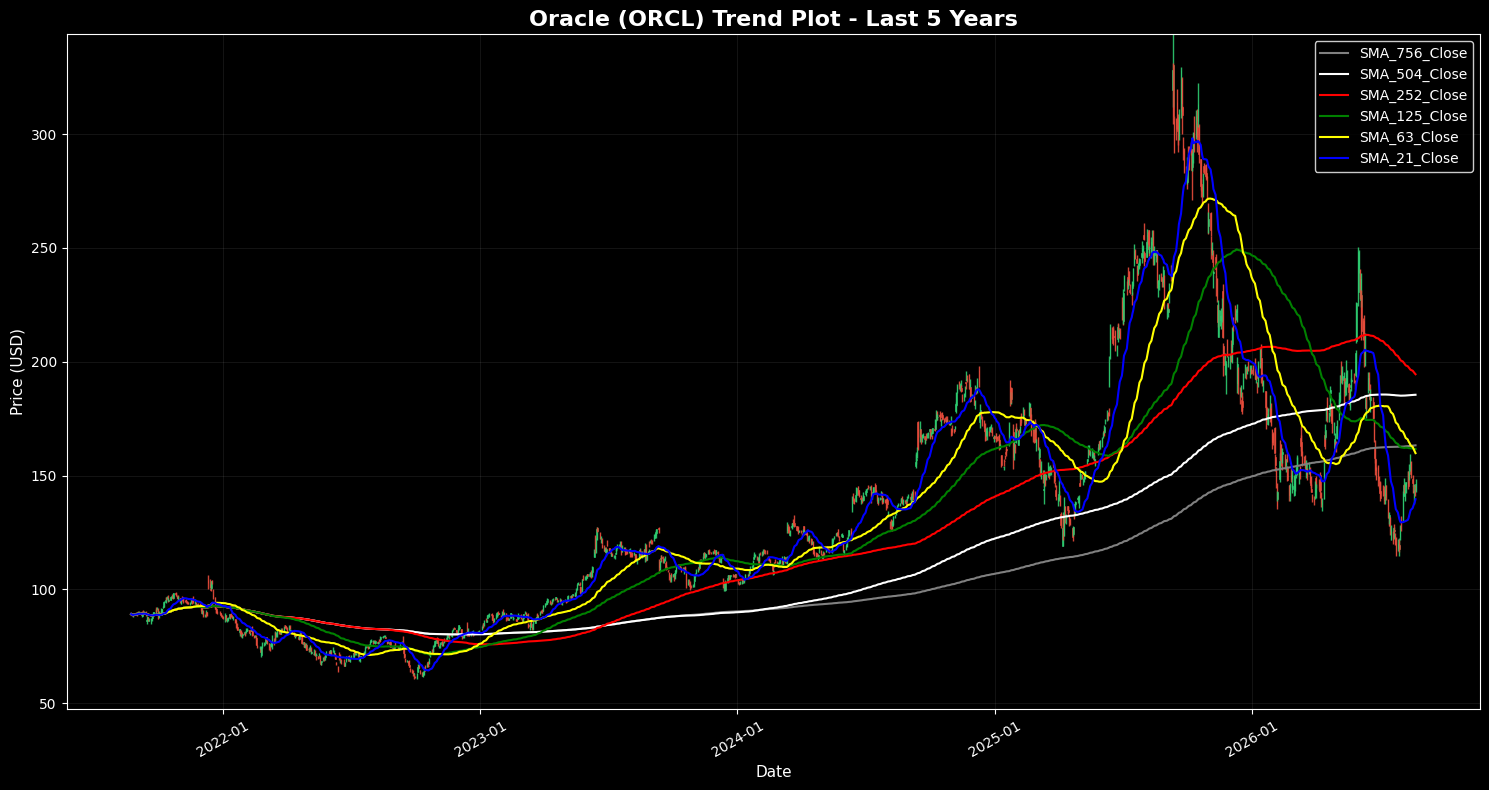

In [46]:
# Static ORCL trend chart for the last 5 years
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Use the cleaned dataframe if available; otherwise create a fallback sample dataset.
if 'df' in globals() and not df.empty:
    static_df = df.reset_index().rename(columns={'time': 'Date'})
    static_df = static_df[['Date', 'open', 'high', 'low', 'close']].copy()
    static_df['Date'] = pd.to_datetime(static_df['Date'])
else:
    np.random.seed(42)
    dates = pd.date_range(start='2020-01-01', periods=1825, freq='D')
    base = 30 + np.cumsum(np.random.normal(0, 1.8, len(dates)))
    opens = base.copy()
    closes = opens + np.random.normal(0, 1.3, len(dates))
    highs = np.maximum(opens, closes) + np.abs(np.random.normal(0, 2.2, len(dates)))
    lows = np.minimum(opens, closes) - np.abs(np.random.normal(0, 2.2, len(dates)))
    static_df = pd.DataFrame({
        'Date': dates,
        'open': opens,
        'high': highs,
        'low': lows,
        'close': closes,
    })

# Restrict to the last 5 years.
cutoff = pd.Timestamp.today().normalize() - pd.DateOffset(years=5)
static_df: pd.DataFrame

# Ensure the Date column is timezone-aware UTC everywhere
static_df["Date"] = pd.to_datetime(static_df["Date"], utc=True, errors="coerce")
static_df = static_df.dropna(subset=["Date"]).copy()

# Keep the cutoff in UTC to match the datetime64[ns, UTC] data
cutoff = pd.Timestamp.now(tz="UTC").normalize() - pd.DateOffset(years=5)

static_df = (
    static_df.loc[static_df["Date"] >= cutoff]
    .sort_values(by="Date", ascending=True, kind="mergesort")
    .reset_index(drop=True)
)

# Compute moving averages in the required names.
for window in [756, 504, 252, 125, 63, 21]:
    static_df[f'SMA_{window}_Close'] = static_df['close'].rolling(window=window, min_periods=1).mean()

# Build the figure.
fig, ax = plt.subplots(figsize=(15, 8), facecolor='black')
ax.set_facecolor('black')

# Plot candlesticks.
for i in range(len(static_df)):
    o = static_df.iloc[i]['open']
    c = static_df.iloc[i]['close']
    h = static_df.iloc[i]['high']
    l = static_df.iloc[i]['low']
    color = '#2ecc71' if c >= o else '#e74c3c'
    x = mdates.date2num(static_df.iloc[i]['Date'])
    ax.vlines(x, l, h, color=color, linewidth=1.0, alpha=0.9)
    rect = plt.Rectangle(
        (x - 0.35, min(o, c)),
        0.7,
        max(abs(c - o), 0.01),
        facecolor=color,
        edgecolor=color,
        linewidth=0.5,
        alpha=0.9,
    )
    ax.add_patch(rect)

# Plot SMAs with the required colors.
line_colors = {
    'SMA_756_Close': 'gray',
    'SMA_504_Close': 'white',
    'SMA_252_Close': 'red',
    'SMA_125_Close': 'green',
    'SMA_63_Close': 'yellow',
    'SMA_21_Close': 'blue',
}

for column, color in line_colors.items():
    ax.plot(static_df['Date'], static_df[column], color=color, linewidth=1.5, label=column)

# Style the chart.
ax.set_title('Oracle (ORCL) Trend Plot - Last 5 Years', color='white', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', color='white', fontsize=11)
ax.set_ylabel('Price (USD)', color='white', fontsize=11)
ax.tick_params(axis='x', colors='white', labelrotation=30)
ax.tick_params(axis='y', colors='white')
ax.grid(True, color='white', alpha=0.08)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

for spine in ax.spines.values():
    spine.set_color('white')

legend = ax.legend(loc='upper right', frameon=True, facecolor='black', edgecolor='white')
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.show()


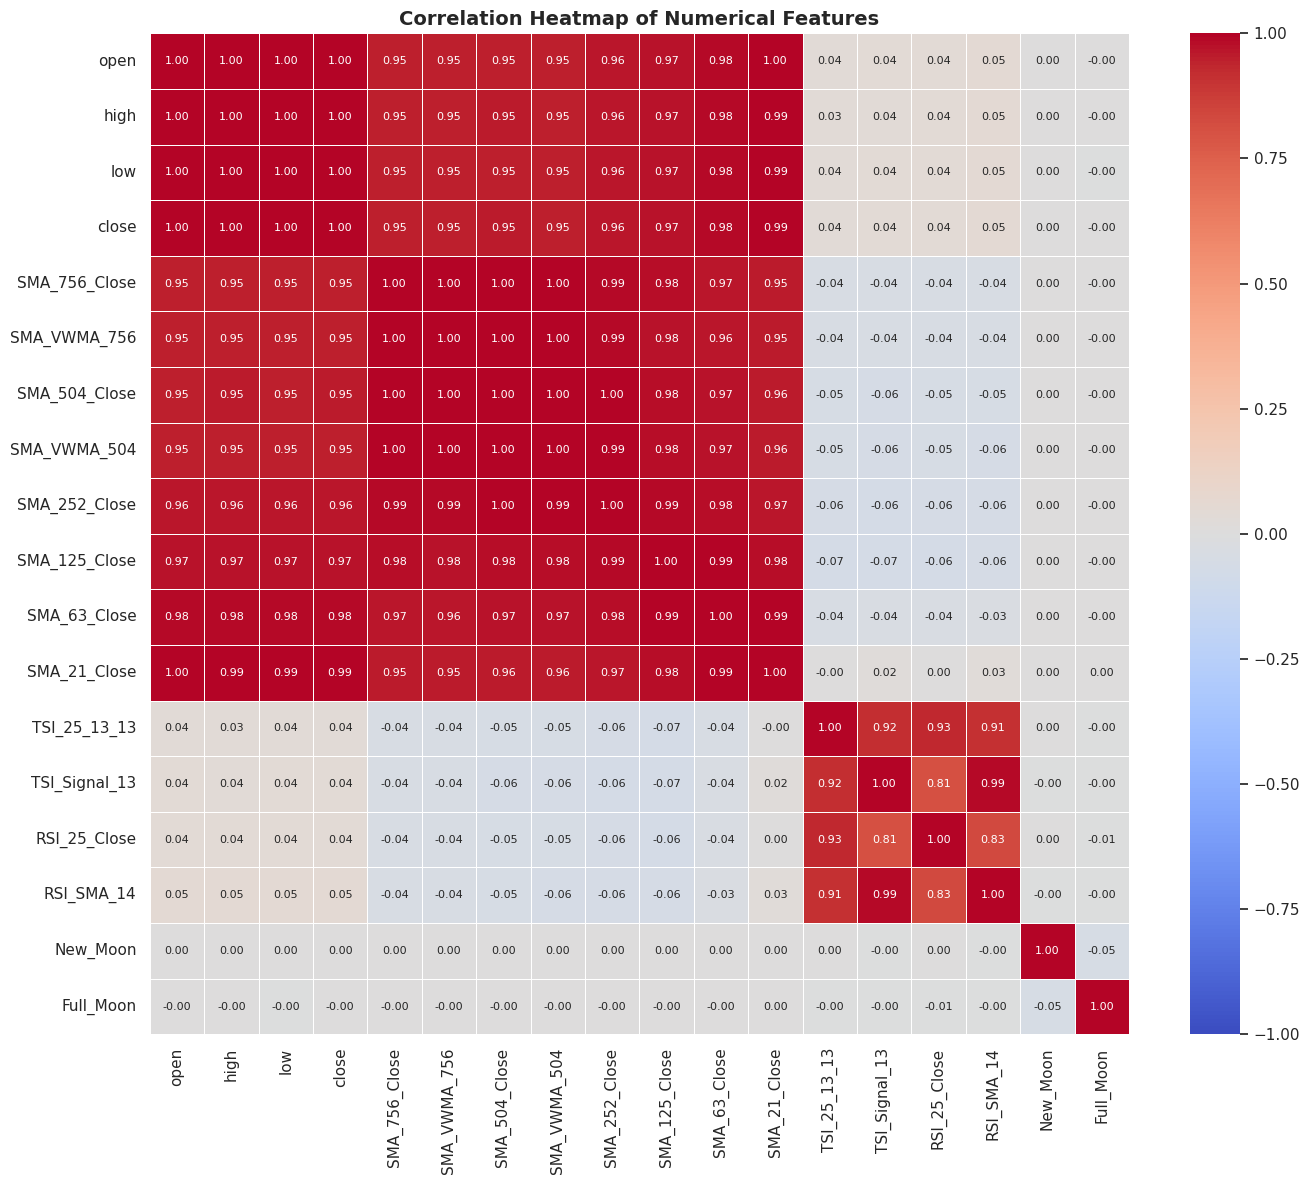

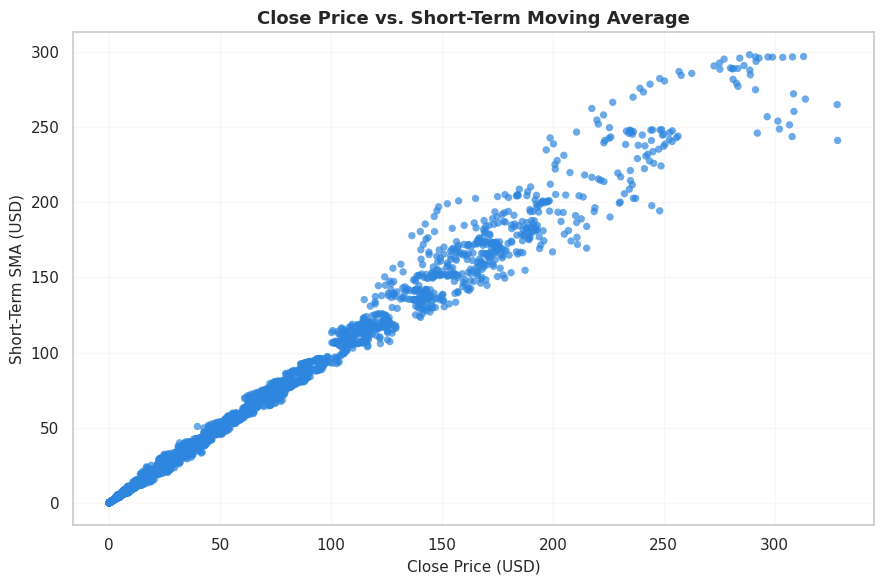

In [59]:
# Correlation heatmap, scatter/histogram, and historical seasonality table
import seaborn as sns

# Use the cleaned dataset for analysis.
df_model = df.copy()

# 1) Correlation heatmap with annotations
numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df_model[numeric_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar=True,
    square=False,
    annot_kws={'size': 8},
    ax=ax
)
ax.set_title('Correlation Heatmap of Numerical Features', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

# 2) Scatter plot (close vs. short-term SMA)
scatter_cols = ['close', 'SMA_21_Close'] if 'SMA_21_Close' in df_model.columns else ['close', 'SMA_63_Close']
if len(scatter_cols) == 2:
    x_col, y_col = scatter_cols
    sns.set_theme(style='whitegrid')

    fig, ax = plt.subplots(figsize=(9, 6))
    sns.scatterplot(
        data=df_model,
        x=x_col,
        y=y_col,
        ax=ax,
        s=28,
        alpha=0.7,
        color='#2E86DE',
        edgecolor='none'
    )

    ax.set_title('Close Price vs. Short-Term Moving Average', fontsize=13, weight='bold')
    ax.set_xlabel('Close Price (USD)', fontsize=11)
    ax.set_ylabel('Short-Term SMA (USD)', fontsize=11)
    ax.grid(True, alpha=0.15)

    plt.tight_layout()
    plt.show()
else:
    print('Insufficient numeric columns for scatter plot view.')


In [60]:
from IPython.display import display, HTML

seasonality_df = df_model.copy()
seasonality_df["year"] = seasonality_df.index.year
seasonality_df["month"] = seasonality_df.index.month

month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

monthly = seasonality_df.groupby(["year", "month"]).agg(
    open_start=("open", "first"),
    close_end=("close", "last"),
    vol_month=("close", "std"),
    avg_vol_month=("volume", "mean") if "volume" in seasonality_df.columns else ("close", "std")
)
monthly["ret_month_pct"] = ((monthly["close_end"] - monthly["open_start"]) / monthly["open_start"]) * 100

annual = seasonality_df.groupby("year").agg(
    open_start=("open", "first"),
    close_end=("close", "last"),
    vol_year=("close", "std"),
    avg_vol_year=("volume", "mean") if "volume" in seasonality_df.columns else ("close", "std")
)
annual["ret_year_pct"] = ((annual["close_end"] - annual["open_start"]) / annual["open_start"]) * 100

seasonality_rows = sorted(seasonality_df["year"].unique())
seasonality_cols = [month_names[m] for m in range(1, 13)] + ["Annual"]

table_data = []

for yr in seasonality_rows:
    row = []
    for m in range(1, 13):
        month_key = (yr, m)
        if month_key in monthly.index:
            value = monthly.loc[month_key, "ret_month_pct"]
            row.append(f"{value:.1f}%")
        else:
            row.append("")
    row.append(f"{annual.loc[yr, 'ret_year_pct']:.1f}%")
    table_data.append(row)

seasonality_table = pd.DataFrame(table_data, index=seasonality_rows, columns=seasonality_cols)
seasonality_table.index.name = "Year"

display(HTML("""
<div style="font-family: Arial, sans-serif; margin-bottom: 10px;">
    <div style="font-size: 15px; font-weight: 700; color: #111111;">
        Oracle (ORCL) Historical Seasonality Table with Monthly and Annual Return Percentages
    </div>
</div>
"""))

def color_return(value):
    if pd.isna(value) or str(value).strip() == "":
        return "background-color: white; color: #111111"
    value_num = float(str(value).replace("%", ""))
    if value_num > 0:
        return "background-color: #d9f2dd; color: #111111"
    elif value_num < 0:
        return "background-color: #f9d7d5; color: #111111"
    return "background-color: white; color: #111111"

styled_table = (
    seasonality_table.style
    .set_properties(**{
        "background-color": "white",
        "color": "#111111",
        "border": "1px solid #d9d9d9",
        "padding": "8px 10px",
        "text-align": "center",
        "font-size": "12px"
    })
    .set_table_styles([
        {"selector": "th", "props": [
            ("background-color", "#f5f5f5"),
            ("color", "#111111"),
            ("font-weight", "bold"),
            ("border", "1px solid #d9d9d9"),
            ("padding", "8px 10px")
        ]},
        {"selector": "td", "props": [
            ("border", "1px solid #d9d9d9"),
            ("padding", "8px 10px")
        ]}
    ])
    .applymap(color_return)
)

styled_table

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
Year,,,,,,,,,,,,,
1986,,,1.2%,26.6%,-6.0%,3.7%,-36.4%,6.5%,-13.6%,26.3%,21.1%,-3.5%,1.2%
1987,30.1%,42.6%,14.3%,6.8%,16.0%,-18.3%,2.2%,17.6%,21.5%,-23.1%,-13.0%,33.3%,179.5%
1988,-3.4%,8.0%,7.4%,3.1%,0.0%,17.9%,-3.8%,-2.6%,8.8%,-21.7%,9.5%,13.0%,34.5%
1989,21.2%,-4.8%,7.2%,20.2%,6.1%,-2.5%,-0.8%,22.0%,26.0%,-1.6%,3.2%,-2.6%,139.7%
1990,-8.0%,4.1%,-15.6%,-15.9%,24.4%,17.1%,-27.0%,-31.1%,-44.1%,-17.3%,46.5%,0.0%,-66.3%
1991,14.3%,0.0%,1.4%,2.8%,-18.9%,13.3%,7.4%,23.3%,18.9%,17.8%,-14.3%,7.4%,84.1%
1992,27.6%,8.1%,-32.1%,3.7%,7.2%,3.4%,11.2%,-4.8%,14.3%,11.9%,0.0%,27.5%,95.7%
1993,15.0%,0.4%,11.4%,-2.7%,16.8%,18.0%,2.3%,2.7%,19.2%,-3.5%,6.5%,-10.9%,103.5%
1994,11.7%,2.7%,-3.4%,-4.8%,14.2%,9.9%,2.0%,11.2%,1.5%,6.7%,-9.8%,7.6%,53.5%
